# 01 · Data Profiling & Quality

This notebook profiles the **pre-cleaned** benchmark dataset before analysis.
Cleaning (outlier removal + unit conversion) was already performed by
`notebooks/01_data_cleaning.ipynb`, which produced `results/results_clean_runs.csv`.

**Cleaning pipeline (upstream):**
- Outliers removed per **(language × benchmark)** group using the 1.5×IQR boxplot fence,
  applied to both CPU energy and execution time
- Units converted: µJ → J, µs → ms, µg → g, Bytes → MB, mW → W

**This notebook covers:**
- Column overview and descriptive statistics
- Missing value check
- Metric distributions
- Data coverage (languages × benchmarks)
- Per-language summary table

**Dataset:** 18 languages × 8 benchmarks, measured with the Green Metrics Tool (GMT).
**Priority metrics:** CPU Energy (J), Memory Energy (J), Execution Time (ms)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from itertools import combinations
from pathlib import Path
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 150, 'figure.figsize': (12, 6)})

In [9]:
# ── Column names as they appear in results_clean_runs.csv ────────────────────
# Units already converted by notebooks/01_data_cleaning.ipynb
COL_CPU_ENERGY = 'cpu_energy_rapl_msr_component-package_0-j'
COL_MEM_ENERGY = 'memory_energy_rapl_msr_component-dram_0-j'
COL_TIME       = 'phase_time_syscall_system-system-ms'
COL_CPU_CARBON = 'cpu_carbon_rapl_msr_component-package_0-g'
COL_MEM_CARBON = 'memory_carbon_rapl_msr_component-dram_0-g'

ALPHA = 0.05

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR = Path('outputs')
OUTPUTS_DIR.mkdir(exist_ok=True)

LANG_DISPLAY = {
    'c': 'C', 'cpp': 'C++', 'csharp': 'C#', 'fsharp': 'F#',
    'nodejs': 'JavaScript', 'dart': 'Dart', 'erlang': 'Erlang',
    'go': 'Go', 'haskell': 'Haskell', 'java': 'Java', 'lua': 'Lua',
    'ocaml': 'OCaml', 'perl': 'Perl', 'php': 'PHP',
    'python': 'Python', 'ruby': 'Ruby', 'rust': 'Rust', 'swift': 'Swift',
}

PARADIGM = {
    'C': 'AOT', 'C++': 'AOT', 'C#': 'AOT', 'Dart': 'AOT', 'Go': 'AOT',
    'Haskell': 'AOT', 'Java': 'AOT', 'OCaml': 'AOT', 'Rust': 'AOT', 'Swift': 'AOT',
    'Erlang': 'JIT', 'F#': 'JIT', 'JavaScript': 'JIT', 'PHP': 'JIT', 'Ruby': 'JIT',
    'Lua': 'Interpreted', 'Perl': 'Interpreted', 'Python': 'Interpreted',
}

PARADIGM_COLORS = {'AOT': '#2980b9', 'JIT': '#e67e22', 'Interpreted': '#27ae60'}
PARADIGM_ORDER  = ['AOT', 'JIT', 'Interpreted']

# Marker style for the mean (▲) overlaid on boxplots/violins (showmeans=True).
MEANPROPS = dict(marker='^', markerfacecolor='white', markeredgecolor='black', markersize=6)

# Data pre-cleaned by notebooks/01_data_cleaning.ipynb:
#   - Outliers removed per (language × benchmark) group, IQR fence on CPU energy + time
#   - Units already converted (J, ms, g, MB, W)
#
# Single source: results_clean_runs.csv — per-run rows.
#   df       = all per-run rows, used for distribution views and non-parametric tests.
#   df_mean  = per-(language × benchmark) mean, computed here from df.
#              Rankings, heatmaps and summary tables use df_mean via lang_means().
df = pd.read_csv('../../results/results_clean_runs.csv')
df['language'] = df['language'].replace(LANG_DISPLAY)
df['paradigm'] = df['language'].map(PARADIGM)

_id_cols = {'run_id', 'measured_at', 'language', 'benchmark', 'paradigm'}
_metric_cols = [c for c in df.columns if c not in _id_cols]
df_mean = df.groupby(['language', 'benchmark'])[_metric_cols].mean().reset_index()
df_mean['paradigm'] = df_mean['language'].map(PARADIGM)

# Energy-Delay Product from representative (mean) values per cell: lower is better.
# EDP = (CPU + Memory energy) × time, in J·ms.
df_mean['EDP'] = (df_mean[COL_CPU_ENERGY] + df_mean[COL_MEM_ENERGY]) * df_mean[COL_TIME]


def lang_means(cols):
    """Per-language two-step mean for column(s) `cols` (str or list): average the
    per-benchmark cell means with equal benchmark weight. Returns a Series for a
    single column or a DataFrame for a list. Derived from results_clean_runs.csv."""
    return df_mean.groupby('language')[cols].mean()


print(f"Runs shape: {df.shape} | Cell-means shape: {df_mean.shape}")
print(f"Languages ({df['language'].nunique()}): {sorted(df['language'].unique())}")
print(f"Benchmarks ({df['benchmark'].nunique()}): {sorted(df['benchmark'].unique())}")
print("Units: energy=J | time=ms | carbon=g | disk/net=MB | power=W")
print("Rankings use the two-step mean (equal benchmark weight) via lang_means(); "
      "boxplots/violins and non-parametric tests use the per-run df.")
df_mean.head(3)

Runs shape: (1280, 17) | Cell-means shape: (144, 16)
Languages (18): ['C', 'C#', 'C++', 'Dart', 'Erlang', 'F#', 'Go', 'Haskell', 'Java', 'JavaScript', 'Lua', 'OCaml', 'PHP', 'Perl', 'Python', 'Ruby', 'Rust', 'Swift']
Benchmarks (8): ['binary-trees', 'fannkuch-redux', 'fasta', 'k-nucleotide', 'mandelbrot', 'n-body', 'regex-redux', 'spectral-norm']
Units: energy=J | time=ms | carbon=g | disk/net=MB | power=W
Rankings use the two-step mean (equal benchmark weight) via lang_means(); boxplots/violins and non-parametric tests use the per-run df.


,language,benchmark,cpu_carbon_rapl_msr_component-package_0-g,cpu_energy_rapl_msr_component-package_0-j,disk_total_read_cgroup_container-container-mb,disk_total_write_cgroup_container-container-mb,embodied_carbon_share_machine-system-g,memory_carbon_rapl_msr_component-dram_0-g,memory_energy_rapl_msr_component-dram_0-j,network_carbon_formula_global-formula-g,network_energy_formula_global-formula-j,network_power_formula_global-formula-w,network_total_cgroup_container-container-mb,phase_time_syscall_system-system-ms,paradigm,EDP
0,C,binary-trees,0.002967,31.976886,0.192512,0.0,0.001753,0.000122,1.311170,0.000000e+00,0.000000,0.0,0.000000,1221.817400,AOT,40671.925300
1,C,fannkuch-redux,0.006453,69.556996,0.000000,0.0,0.003131,0.000063,0.682479,5.714286e-07,0.005702,0.0,0.000039,2182.097714,AOT,153269.397538
2,C,fasta,0.003574,38.523294,0.000000,0.0,0.002074,0.000081,0.870375,1.666667e-06,0.018067,0.0,0.000122,1445.462222,AOT,56942.061458


## 1. Column Overview

Extended `describe()` supplemented with median and IQR for the three priority columns.
Median is preferred over mean for right-skewed benchmark distributions.
All values are in human-readable units (J for energy, ms for time).

In [10]:
priority = [COL_CPU_ENERGY, COL_MEM_ENERGY, COL_TIME]
labels   = {COL_CPU_ENERGY: 'CPU Energy (J)',
            COL_MEM_ENERGY: 'Mem Energy (J)',
            COL_TIME:       'Time (ms)'}

stats_tbl = df[priority].describe().T
stats_tbl['median'] = df[priority].median()
stats_tbl['IQR']    = df[priority].quantile(0.75) - df[priority].quantile(0.25)
stats_tbl['skew']   = df[priority].skew()
stats_tbl.index     = [labels[c] for c in stats_tbl.index]
stats_tbl.round(4)

,count,mean,std,min,25%,50%,75%,max,median,IQR,skew
CPU Energy (J),1280.0,878.6371,1841.3281,8.6440,54.8354,181.9181,713.4515,12092.7936,181.9181,658.6161,3.7003
Mem Energy (J),1280.0,18.2485,67.5367,0.1484,1.2021,3.2025,15.1225,748.1624,3.2025,13.9203,9.7983
Time (ms),1280.0,33876.0128,70458.1506,393.0890,2533.4175,6642.6450,29441.9078,413484.9140,6642.6450,26908.4902,3.3506


## 2. Missing Values

Completeness check across all 16 columns. Benchmark datasets often contain zeros rather
than NaN for metrics that were not triggered (e.g. network bytes on a CPU-only task).

In [11]:
null_counts = df.isnull().sum()
if null_counts.sum() == 0:
    print("✓ No missing values — dataset is complete.")
else:
    print("Missing values detected:")
    print(null_counts[null_counts > 0])

# Check for zero-only columns (may indicate inactive metrics)
zero_frac = (df[priority] == 0).mean()
print("\nFraction of zeros in priority columns:")
for col, frac in zip(['CPU Energy', 'Mem Energy', 'Time'], zero_frac):
    print(f"  {col}: {frac:.1%}")

✓ No missing values — dataset is complete.

Fraction of zeros in priority columns:
  CPU Energy: 0.0%
  Mem Energy: 0.0%
  Time: 0.0%


## 3. Distributions

Histograms on a log₁₀ scale for the three priority metrics.
Benchmark data is typically right-skewed (a few languages/benchmarks dominate the upper tail).
Values are in J (energy) and ms (time).
A divergence of >20% between mean and median is flagged.

/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_58155/466486622.py:22: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_58155/466486622.py:22: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_58155/466486622.py:22: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_58155/466486622.py:23: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(FIGURES_DIR / 'distributions.png', bbox_inches='tight')
/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_58155/466486622.py:23: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(FIGURES_DIR / 'distributions.png', bbox_inches='tight')
/var/folders/42/3rphxfts3x

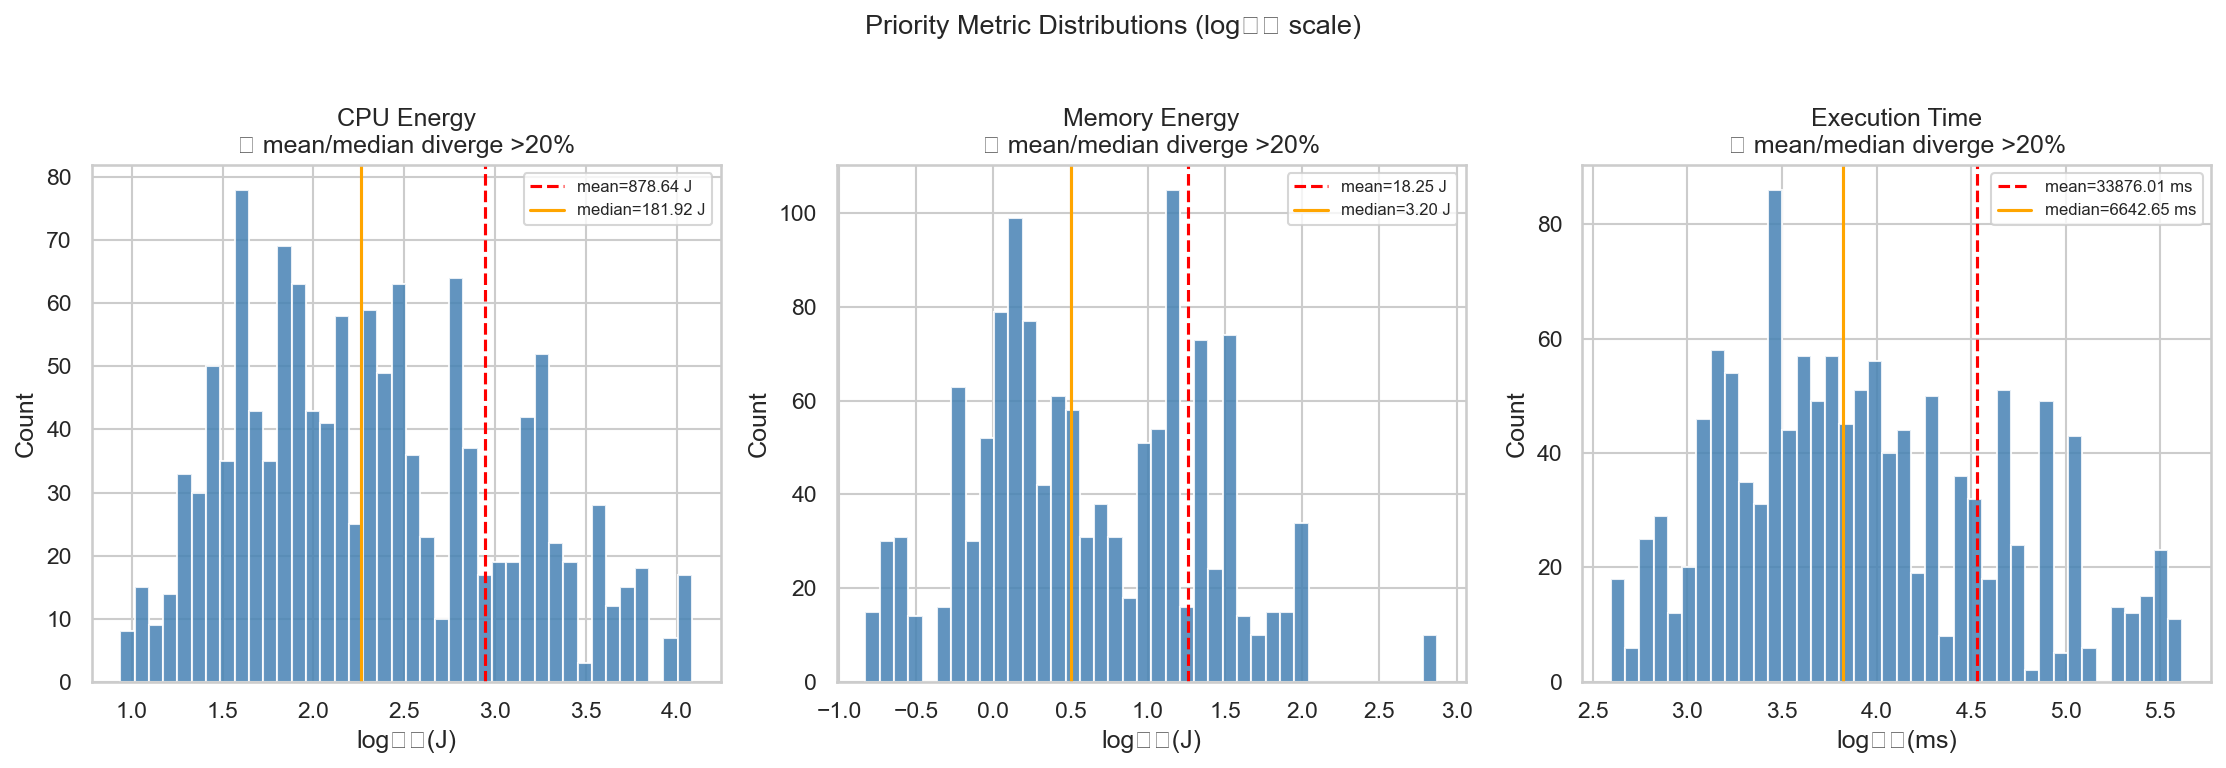

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metric_info = [
    ('CPU Energy', COL_CPU_ENERGY, 'J'),
    ('Memory Energy', COL_MEM_ENERGY, 'J'),
    ('Execution Time', COL_TIME, 'ms'),
]
for ax, (label, col, unit) in zip(axes, metric_info):
    vals = df[col][df[col] > 0]
    log_vals = np.log10(vals)
    ax.hist(log_vals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    mean_v, med_v = vals.mean(), vals.median()
    ax.axvline(np.log10(mean_v), color='red',    linestyle='--', label=f'mean={mean_v:.2f} {unit}')
    ax.axvline(np.log10(med_v),  color='orange', linestyle='-',  label=f'median={med_v:.2f} {unit}')
    ax.set_title(f'{label}')
    ax.set_xlabel(f'log₁₀({unit})')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    if abs(mean_v - med_v) / med_v > 0.20:
        ax.set_title(ax.get_title() + '\n⚠ mean/median diverge >20%')

fig.suptitle('Priority Metric Distributions (log₁₀ scale)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'distributions.png', bbox_inches='tight')
plt.show()

## 4. Data Coverage

Heatmap showing the number of runs for each language × benchmark pair.
A uniform count across all cells indicates balanced coverage.

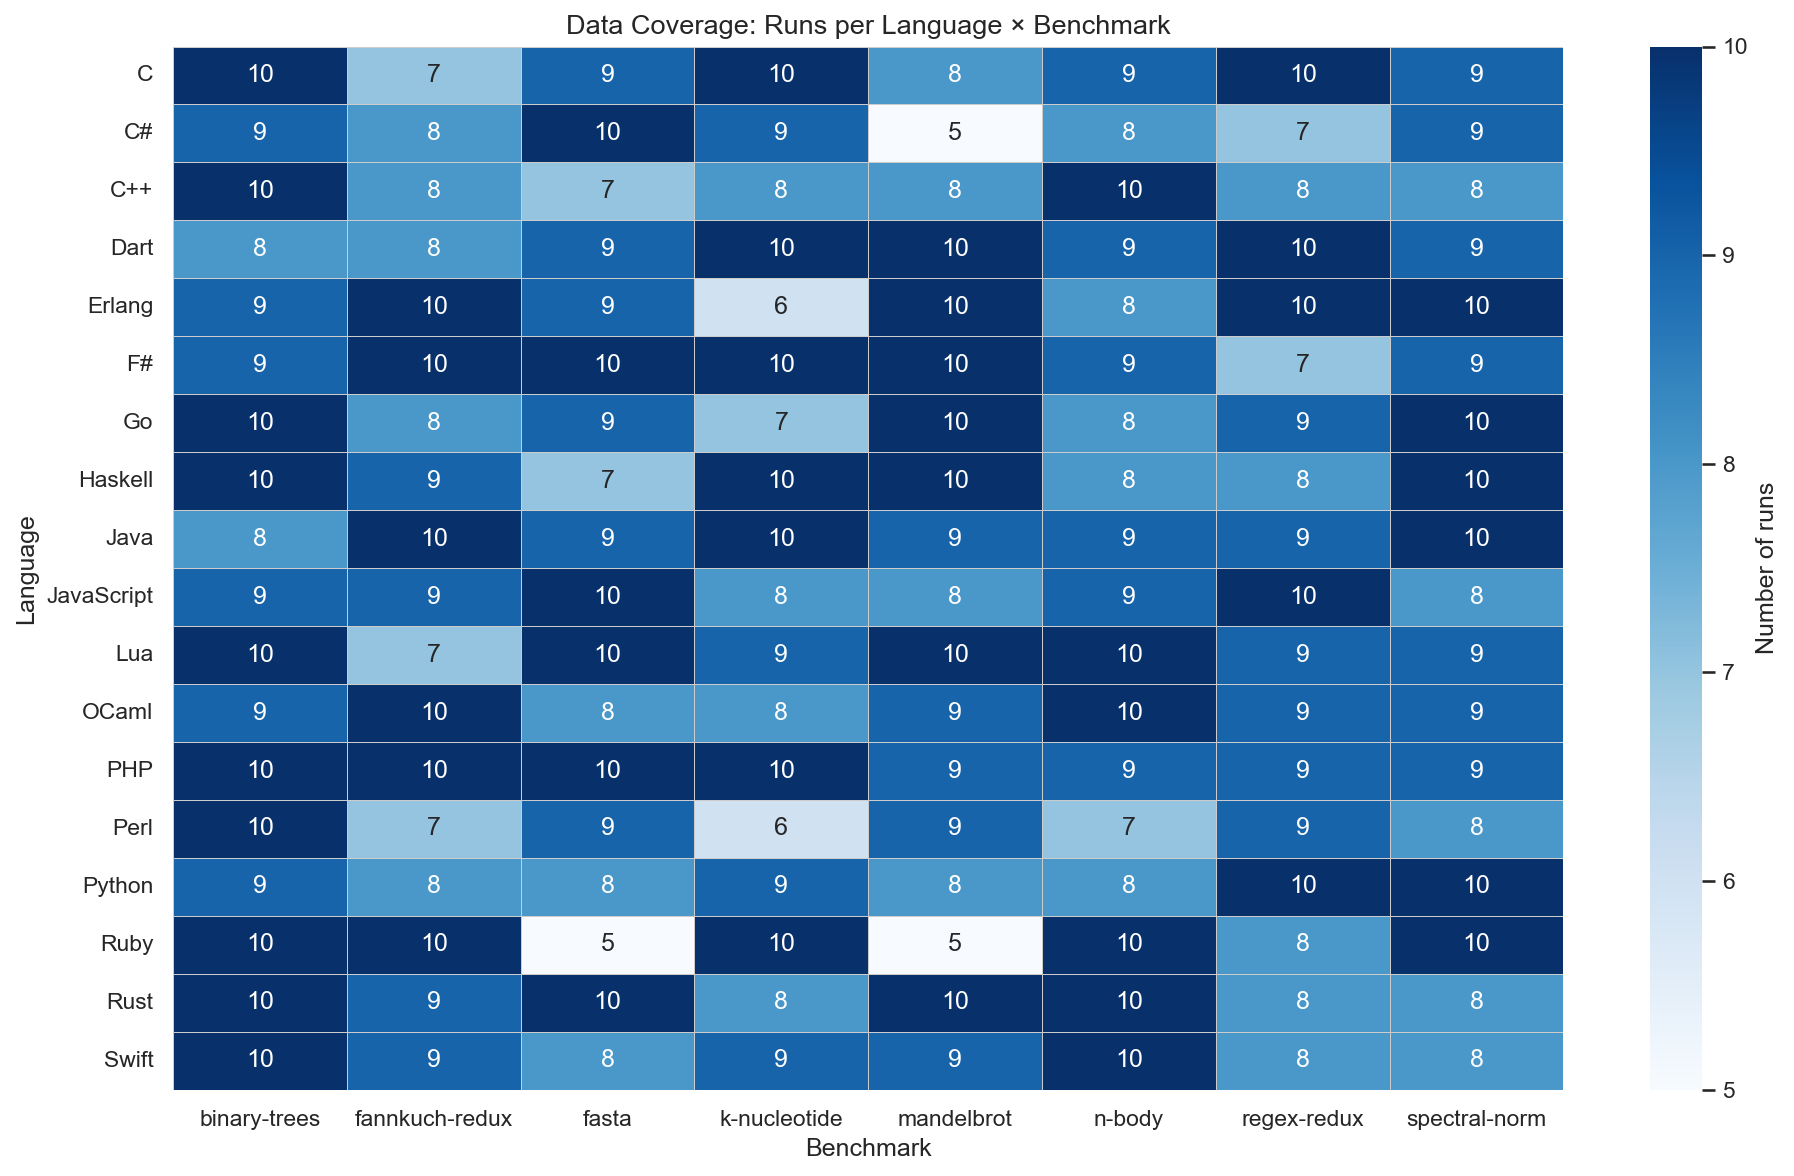

Min runs in any cell: 5
Max runs in any cell: 10
Mean runs per cell:   8.9


In [13]:
coverage = df.groupby(['language', 'benchmark']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(coverage, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.4, linecolor='#ccc',
            cbar_kws={'label': 'Number of runs'})
ax.set_title('Data Coverage: Runs per Language × Benchmark', fontsize=13)
ax.set_xlabel('Benchmark')
ax.set_ylabel('Language')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'coverage_heatmap.png', bbox_inches='tight')
plt.show()
print(f"Min runs in any cell: {coverage.values.min()}")
print(f"Max runs in any cell: {coverage.values.max()}")
print(f"Mean runs per cell:   {coverage.values.mean():.1f}")

## 5. Summary Table

Per-language descriptive statistics for all three priority metrics in human-readable units.
Mean and median are both reported; large divergence signals skewness within a language.

In [14]:
summary_tbl = df.groupby('language').agg(
    paradigm      = ('paradigm', 'first'),
    runs          = ('run_id', 'count'),
    cpu_mean_J    = (COL_CPU_ENERGY, 'mean'),
    cpu_median_J  = (COL_CPU_ENERGY, 'median'),
    mem_mean_J    = (COL_MEM_ENERGY, 'mean'),
    mem_median_J  = (COL_MEM_ENERGY, 'median'),
    time_mean_ms   = (COL_TIME, 'mean'),
    time_median_ms = (COL_TIME, 'median'),
).round(4)

# Flag skew
for label, mc, mdc in [('CPU energy', 'cpu_mean_J', 'cpu_median_J'),
                        ('Mem energy', 'mem_mean_J', 'mem_median_J'),
                        ('Time',       'time_mean_ms','time_median_ms')]:
    skew_mask = (abs(summary_tbl[mc] - summary_tbl[mdc]) / summary_tbl[mdc]) > 0.20
    if skew_mask.any():
        print(f"⚠ {label} mean/median diverge >20% for: {list(summary_tbl.index[skew_mask])}")

summary_tbl.sort_values('cpu_median_J')

⚠ CPU energy mean/median diverge >20% for: ['C', 'C++', 'Dart', 'F#', 'Go', 'Haskell', 'Java', 'JavaScript', 'Lua', 'PHP', 'Perl', 'Python', 'Ruby', 'Rust', 'Swift']
⚠ Mem energy mean/median diverge >20% for: ['C', 'C#', 'C++', 'Dart', 'Erlang', 'F#', 'Go', 'Haskell', 'Java', 'JavaScript', 'Lua', 'OCaml', 'PHP', 'Perl', 'Python', 'Ruby', 'Rust', 'Swift']
⚠ Time mean/median diverge >20% for: ['C', 'C#', 'C++', 'Dart', 'Erlang', 'F#', 'Go', 'Haskell', 'JavaScript', 'Lua', 'OCaml', 'PHP', 'Perl', 'Python', 'Rust', 'Swift']


,paradigm,runs,cpu_mean_J,cpu_median_J,mem_mean_J,mem_median_J,time_mean_ms,time_median_ms
language,,,,,,,,
C++,AOT,67,47.0008,27.4833,1.2443,0.8635,1988.0399,1589.6770
Rust,AOT,73,82.4563,34.5609,1.3708,0.8075,3068.7434,1823.9870
C,AOT,72,55.0583,38.6266,1.1425,0.8623,2099.3463,1530.2810
Haskell,AOT,72,179.2048,54.4325,5.1110,2.5517,5879.4837,2182.2610
C#,AOT,65,66.9278,69.2345,2.4913,1.4670,2807.8748,2218.2670
F#,JIT,74,116.0869,94.1421,3.1945,1.4065,4058.5678,3126.3345
Go,AOT,71,153.4139,97.3902,4.2670,1.5326,5900.8984,4019.5680
Java,AOT,74,135.5141,109.5482,3.9344,1.9212,5080.9477,4332.9695
JavaScript,JIT,71,166.1552,117.3401,5.5685,2.4833,7337.1413,5575.2020
